# Tutorial: Redes Neurais com TensorFlow/Keras

**Objetivo:** aprender, do zero e com base em primeiros princípios, como construir, treinar e avaliar redes neurais usando TensorFlow e sua API de alto nível Keras.

**Pré-requisitos:** Python básico, NumPy, conceitos elementares de aprendizado supervisionado (treino/teste, métricas, overfitting).

**Estrutura do tutorial:**

| Módulo | Tópico |
|---|---|
| 01 | Setup e verificação do ambiente |
| 02 | Tensores: a estrutura de dados fundamental |
| 03 | Construindo um neurônio do zero |
| 04 | Primeira rede: regressão linear com a Sequential API |
| 05 | MLP para regressão não-linear |
| 06 | Classificação binária |
| 07 | Classificação multiclasse com Fashion-MNIST |
| 08 | Combatendo o overfitting |
| 09 | Salvar, carregar e reutilizar modelos |
| 10 | Laboratório final |

Cada módulo termina com uma seção **Laboratório**: pequenos exercícios para fixação. O código inicial é deliberadamente mínimo — a ideia é construir o conhecimento na prática.


---
## Módulo 01 — Setup e verificação do ambiente

Antes de qualquer coisa, garantimos que as bibliotecas necessárias estão instaladas e que o TensorFlow está funcionando.


In [ ]:
# Descomente as linhas abaixo na primeira execução do notebook
# !pip install tensorflow
# !pip install matplotlib scikit-learn

### Importações principais

Note a separação:
- `tensorflow` é o framework completo (tensores, autograd, GPU).
- `keras` é a API de alto nível para construir e treinar modelos.
- `layers` traz os blocos de construção (camadas) prontos.


In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

import numpy as np
import matplotlib.pyplot as plt

# Reprodutibilidade
np.random.seed(42)
tf.random.set_seed(42)

print(f"TensorFlow versão: {tf.__version__}")
print(f"Keras versão:      {keras.__version__}")
print(f"GPU disponível:    {len(tf.config.list_physical_devices('GPU')) > 0}")

TensorFlow versão: 2.20.0
Keras versão:      3.13.2
GPU disponível:    False


**Observação:** rodar em CPU é perfeitamente aceitável para este tutorial. GPU só faz diferença em redes grandes ou datasets pesados (imagens, NLP).

---
## Módulo 02 — Tensores: a estrutura de dados fundamental

Um **tensor** é apenas um array multidimensional — generalização de escalares, vetores e matrizes:

| Rank | Nome | Exemplo |
|---|---|---|
| 0 | escalar | `5` |
| 1 | vetor | `[1, 2, 3]` |
| 2 | matriz | `[[1, 2], [3, 4]]` |
| 3+ | tensor n-D | imagem RGB `(altura, largura, canais)` |

Todo o TensorFlow opera sobre tensores. Pense em um tensor como um `numpy.ndarray` turbinado: roda em GPU, calcula gradientes automaticamente e se integra com o grafo computacional do Keras.


In [2]:
# Criando tensores
escalar = tf.constant(7)
vetor = tf.constant([1.0, 2.0, 3.0])
matriz = tf.constant([[1, 2], [3, 4]])

print("Escalar:", escalar, "\n")
print("Vetor:", vetor, "\n")
print("Matriz:", matriz)

Escalar: tf.Tensor(7, shape=(), dtype=int32) 

Vetor: tf.Tensor([1. 2. 3.], shape=(3,), dtype=float32) 

Matriz: tf.Tensor(
[[1 2]
 [3 4]], shape=(2, 2), dtype=int32)


In [3]:
# Inspecionando atributos: shape, rank e dtype
print(f"Shape do vetor:   {vetor.shape}")
print(f"Rank da matriz:   {tf.rank(matriz).numpy()}")
print(f"Dtype da matriz:  {matriz.dtype}")

Shape do vetor:   (3,)
Rank da matriz:   2
Dtype da matriz:  <dtype: 'int32'>


In [4]:
# Operações: TensorFlow se parece muito com NumPy
a = tf.constant([[1.0, 2.0], [3.0, 4.0]])
b = tf.constant([[5.0, 6.0], [7.0, 8.0]])

print("Soma elemento a elemento:\n", a + b, "\n")
print("Multiplicação matricial (a @ b):\n", tf.matmul(a, b))

Soma elemento a elemento:
 tf.Tensor(
[[ 6.  8.]
 [10. 12.]], shape=(2, 2), dtype=float32) 

Multiplicação matricial (a @ b):
 tf.Tensor(
[[19. 22.]
 [43. 50.]], shape=(2, 2), dtype=float32)


In [5]:
# Conversão NumPy <-> Tensor é trivial
arr = np.array([10.0, 20.0, 30.0])
t = tf.constant(arr)             # NumPy -> Tensor
de_volta = t.numpy()             # Tensor -> NumPy

print("Tensor a partir de NumPy:", t)
print("NumPy a partir de Tensor:", de_volta)

Tensor a partir de NumPy: tf.Tensor([10. 20. 30.], shape=(3,), dtype=float64)
NumPy a partir de Tensor: [10. 20. 30.]


### Laboratório 02

1. Crie um tensor 3-D de shape `(2, 3, 4)` preenchido com zeros (`tf.zeros`).
2. Crie outro tensor de mesma shape com valores aleatórios uniformes (`tf.random.uniform`).
3. Some os dois e imprima o resultado.
4. Calcule a média ao longo do último eixo usando `tf.reduce_mean(..., axis=-1)`.


In [ ]:
# Seu código aqui


---
## Módulo 03 — Construindo um neurônio do zero

Antes de chamar `Dense`, vamos implementar manualmente o que um neurônio faz. Isso desmistifica completamente o Keras.

Um neurônio executa duas operações:

1. **Combinação linear:** $z = w_1 x_1 + w_2 x_2 + \dots + w_n x_n + b$, ou em forma matricial $z = \mathbf{x} \cdot \mathbf{w} + b$.
2. **Ativação não-linear:** $a = f(z)$, onde $f$ é por exemplo a ReLU, sigmoide, tanh.

É só isso. Toda rede neural é um empilhamento dessas duas operações.


In [6]:
# Entrada: 3 features
x = tf.constant([[1.0, 2.0, 3.0]])  # shape (1, 3) -- 1 amostra, 3 features

# Pesos e viés que normalmente são aprendidos pelo treino
w = tf.Variable([[0.5], [-0.2], [0.1]])  # shape (3, 1)
b = tf.Variable([0.4])                    # shape (1,)

# Etapa 1: combinação linear
z = tf.matmul(x, w) + b
print("Saída linear z:", z.numpy())

Saída linear z: [[0.8]]


In [7]:
# Etapa 2: aplicar uma função de ativação (ReLU: max(0, z))
a = tf.nn.relu(z)
print("Saída após ReLU:", a.numpy())

Saída após ReLU: [[0.8]]


### Agora a versão do Keras

A camada `Dense` faz exatamente o que acabamos de implementar — mas cria os pesos automaticamente e os integra ao mecanismo de treinamento.


In [8]:
# Camada Dense com 1 neurônio e ativação ReLU
neuronio = layers.Dense(units=1, activation='relu')

# Ao receber a entrada, o Keras inicializa pesos automaticamente
saida = neuronio(x)
print("Saída da camada Dense:", saida.numpy())
print("\nPesos aprendíveis dessa camada:")
for var in neuronio.weights:
    print(f"  {var.name}: shape {var.shape}")

Saída da camada Dense: [[0.]]

Pesos aprendíveis dessa camada:
  kernel: shape (3, 1)
  bias: shape (1,)


**Tome um minuto** para perceber: a única diferença entre o "neurônio manual" e o `Dense` é que o Keras gerencia os pesos, a inicialização e a integração com o `fit()`. Nada de mágico.

### Laboratório 03

1. Crie manualmente um "neurônio" com 4 entradas e ativação **sigmoide** (use `tf.nn.sigmoid`).
2. Compare a saída dele com uma `Dense(1, activation='sigmoid')` aplicada à mesma entrada.
3. Os valores serão diferentes — por quê?


In [ ]:
# Seu código aqui


---
## Módulo 04 — Primeira rede: regressão linear com a Sequential API

Vamos resolver o problema mais simples possível: aprender a função $y = 2x + 1$ a partir de dados ruidosos. Isto serve para entender o **fluxo de trabalho completo do Keras**:

1. **Definir** o modelo (`Sequential` + camadas).
2. **Compilar** (escolher otimizador, função de perda e métricas).
3. **Treinar** (`fit`).
4. **Avaliar / prever** (`evaluate`, `predict`).


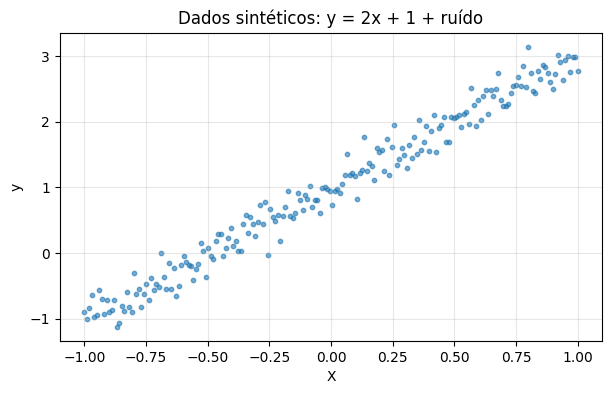

In [9]:
# Gerando dados sintéticos: y = 2x + 1 + ruído
X = np.linspace(-1, 1, 200).reshape(-1, 1).astype(np.float32)
y = (2 * X + 1 + np.random.normal(0, 0.2, X.shape)).astype(np.float32)

plt.figure(figsize=(7, 4))
plt.scatter(X, y, s=10, alpha=0.6)
plt.title("Dados sintéticos: y = 2x + 1 + ruído")
plt.xlabel("X"); plt.ylabel("y")
plt.grid(alpha=0.3)
plt.show()

### Passo 1: definir o modelo

Como é uma regressão linear, basta **uma camada Dense com 1 neurônio e ativação linear** (padrão quando não especificamos).


In [10]:
modelo = keras.Sequential([
    layers.Input(shape=(1,)),     # 1 feature de entrada
    layers.Dense(units=1)         # 1 neurônio, ativação linear (default)
])

modelo.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_1 (Dense)                 │ (None, 1)              │             2 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2 (8.00 B)

 Trainable params: 2 (8.00 B)

 Non-trainable params: 0 (0.00 B)

**Lendo o summary:**
- Coluna **Output Shape** mostra a forma do tensor de saída de cada camada (`None` = batch dinâmico).
- Coluna **Param #** é a contagem de parâmetros aprendíveis. Aqui temos **2**: um peso ($w$) e um viés ($b$). Bate com a fórmula $y = wx + b$.

### Passo 2: compilar

Aqui dizemos ao Keras **como aprender**:
- **otimizador**: algoritmo que atualiza os pesos (Adam, SGD...).
- **loss**: o que minimizar. Para regressão, normalmente `mse` (erro quadrático médio).
- **metrics**: o que monitorar durante o treino (não influencia o aprendizado).


In [11]:
modelo.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

### Passo 3: treinar

`fit` faz o loop: forward pass → calcular loss → backward pass (gradientes) → atualizar pesos. Tudo isso por época, em mini-batches.


In [12]:
historico = modelo.fit(
    X, y,
    epochs=100,
    batch_size=16,
    verbose=0   # silencioso; troque por 1 para ver cada época
)

print("Loss final (MSE):", historico.history['loss'][-1])

Loss final (MSE): 0.8957525491714478


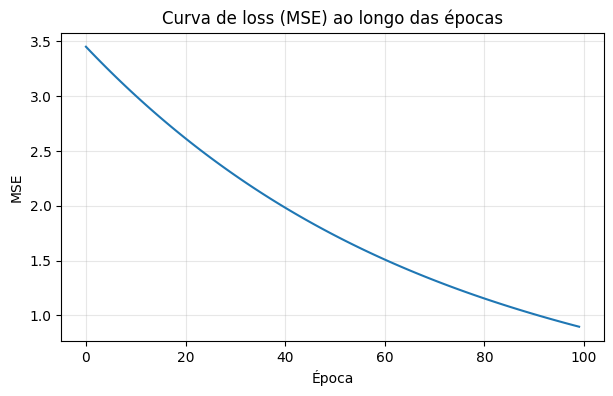

In [13]:
# Visualizando a curva de aprendizado
plt.figure(figsize=(7, 4))
plt.plot(historico.history['loss'])
plt.title("Curva de loss (MSE) ao longo das épocas")
plt.xlabel("Época"); plt.ylabel("MSE")
plt.grid(alpha=0.3)
plt.show()

### Passo 4: inspecionar e prever

Vamos ver se a rede realmente "aprendeu" $w \approx 2$ e $b \approx 1$.


In [14]:
w_aprendido, b_aprendido = modelo.layers[0].get_weights()
print(f"Peso aprendido (w): {w_aprendido[0][0]:.4f}  (esperado ~2)")
print(f"Viés aprendido (b): {b_aprendido[0]:.4f}  (esperado ~1)")

Peso aprendido (w): 0.4543  (esperado ~2)
Viés aprendido (b): 0.8290  (esperado ~1)


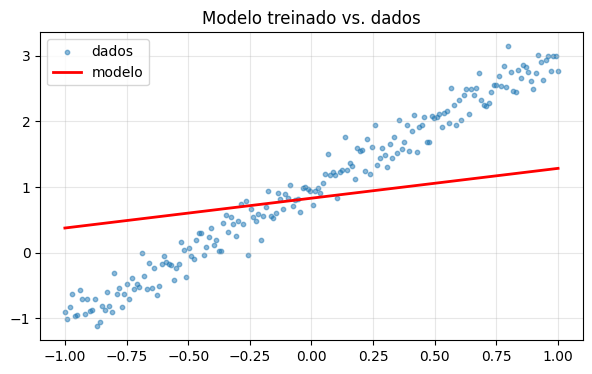

In [15]:
# Fazendo previsões e visualizando
y_pred = modelo.predict(X, verbose=0)

plt.figure(figsize=(7, 4))
plt.scatter(X, y, s=10, alpha=0.5, label="dados")
plt.plot(X, y_pred, color='red', linewidth=2, label="modelo")
plt.title("Modelo treinado vs. dados")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

### Laboratório 04

1. Refaça o experimento, mas com `optimizer='sgd'`. Quantas épocas a mais (ou a menos) você precisou para chegar em um resultado parecido?
2. Aumente o ruído para `0.5` em vez de `0.2`. O que muda nos pesos aprendidos?
3. Tente prever um valor fora do intervalo de treino, por exemplo `modelo.predict([[5.0]])`. O resultado faz sentido? Por que regressões lineares **extrapolam** razoavelmente, mas redes profundas geralmente **não**?


In [ ]:
# Seu código aqui


---
## Módulo 05 — MLP para regressão não-linear

Uma rede com 1 camada linear só consegue aprender funções lineares. Para capturar padrões curvos, precisamos:

1. **Mais camadas** (profundidade).
2. **Ativações não-lineares** entre elas (ReLU é o padrão moderno).

Sem a ativação não-linear, empilhar camadas é matematicamente equivalente a uma só camada. **A não-linearidade é o que dá poder expressivo à rede.**


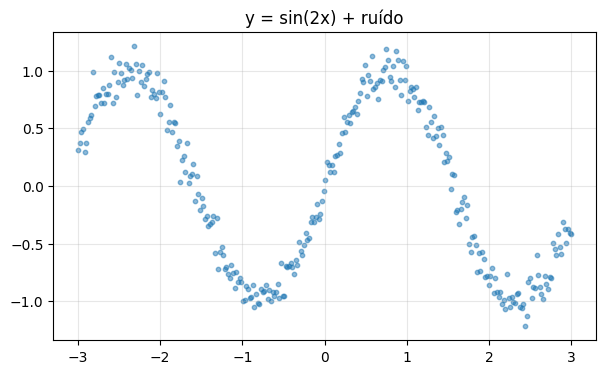

In [16]:
# Função alvo não-linear: y = sin(2x) + ruído pequeno
X = np.linspace(-3, 3, 300).reshape(-1, 1).astype(np.float32)
y = (np.sin(2 * X) + np.random.normal(0, 0.1, X.shape)).astype(np.float32)

plt.figure(figsize=(7, 4))
plt.scatter(X, y, s=10, alpha=0.5)
plt.title("y = sin(2x) + ruído")
plt.grid(alpha=0.3); plt.show()

### Construindo um MLP (Multi-Layer Perceptron)

Vamos usar **duas camadas ocultas** com ReLU e uma camada de saída linear.


In [17]:
mlp = keras.Sequential([
    layers.Input(shape=(1,)),
    layers.Dense(32, activation='relu'),   # camada oculta 1
    layers.Dense(32, activation='relu'),   # camada oculta 2
    layers.Dense(1)                        # saída linear (regressão)
])

mlp.compile(optimizer='adam', loss='mse', metrics=['mae'])
mlp.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 32)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,153 (4.50 KB)

 Trainable params: 1,153 (4.50 KB)

 Non-trainable params: 0 (0.00 B)

**Conte os parâmetros para fixar a intuição:**

- 1ª Dense: 1 entrada × 32 neurônios + 32 vieses = **64 parâmetros**
- 2ª Dense: 32 × 32 + 32 = **1056 parâmetros**
- Saída: 32 × 1 + 1 = **33 parâmetros**
- Total: **1153 parâmetros**

Toda a "inteligência" da rede está nesses números, que serão ajustados pelo `fit`.


In [ ]:
# Treinamento usando validação para monitorar generalização
historico = mlp.fit(
    X, y,
    epochs=200,
    batch_size=32,
    validation_split=0.2,    # separa 20% para validação automaticamente
    verbose=0
)

In [ ]:
# Visualizar treino vs validação
plt.figure(figsize=(7, 4))
plt.plot(historico.history['loss'], label='treino')
plt.plot(historico.history['val_loss'], label='validação')
plt.title("Loss: treino vs validação")
plt.xlabel("Época"); plt.ylabel("MSE")
plt.legend(); plt.grid(alpha=0.3); plt.show()

In [ ]:
# Visualizar predições
y_pred = mlp.predict(X, verbose=0)

plt.figure(figsize=(7, 4))
plt.scatter(X, y, s=10, alpha=0.4, label="dados")
plt.plot(X, y_pred, color='red', linewidth=2, label="MLP")
plt.title("MLP aprendeu a forma da senoide")
plt.legend(); plt.grid(alpha=0.3); plt.show()

### Laboratório 05

1. Refaça o experimento com **apenas uma camada oculta** e mesma quantidade total de neurônios (ex.: `Dense(64)`). A rede consegue capturar a forma da função?
2. Substitua todas as ativações `relu` por `linear`. O que acontece? Por quê?
3. Aumente a frequência da senoide para `sin(5x)`. A rede precisa de mais neurônios? Mais épocas?


In [ ]:
# Seu código aqui


---
## Módulo 06 — Classificação binária

Mudanças em relação à regressão:

| Componente | Regressão | Classificação binária |
|---|---|---|
| Camada de saída | `Dense(1)` linear | `Dense(1, activation='sigmoid')` |
| Loss | `mse` | `binary_crossentropy` |
| Métrica | `mae`, `mse` | `accuracy` |
| Saída | número real | probabilidade ∈ [0, 1] |


In [ ]:
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split

# Dataset "moons" — clássico de não-linearidade
X, y = make_moons(n_samples=1000, noise=0.2, random_state=42)
X = X.astype(np.float32); y = y.astype(np.float32)

X_treino, X_teste, y_treino, y_teste = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Visualização
plt.figure(figsize=(6, 5))
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', s=15, alpha=0.7)
plt.title("Dataset make_moons (classes 0 e 1)")
plt.grid(alpha=0.3); plt.show()

In [ ]:
# Modelo para classificação binária
clf = keras.Sequential([
    layers.Input(shape=(2,)),                # 2 features
    layers.Dense(16, activation='relu'),
    layers.Dense(16, activation='relu'),
    layers.Dense(1, activation='sigmoid')    # probabilidade de classe 1
])

clf.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [ ]:
historico = clf.fit(
    X_treino, y_treino,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=0
)

loss_teste, acc_teste = clf.evaluate(X_teste, y_teste, verbose=0)
print(f"Acurácia no teste: {acc_teste:.4f}")

In [ ]:
# Visualizando a fronteira de decisão aprendida
xx, yy = np.meshgrid(np.linspace(-2, 3, 200), np.linspace(-1.5, 2, 200))
grid = np.c_[xx.ravel(), yy.ravel()].astype(np.float32)
probs = clf.predict(grid, verbose=0).reshape(xx.shape)

plt.figure(figsize=(7, 5))
plt.contourf(xx, yy, probs, levels=20, cmap='coolwarm', alpha=0.6)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='coolwarm', edgecolors='k', s=20)
plt.title("Fronteira de decisão (probabilidade da classe 1)")
plt.grid(alpha=0.3); plt.show()

### Como interpretar a saída de uma sigmoide

A saída da rede é uma **probabilidade** de pertencer à classe 1. Para obter a classe predita usamos um limiar (geralmente 0.5):


In [ ]:
probs = clf.predict(X_teste[:5], verbose=0)
classes = (probs > 0.5).astype(int)

for i in range(5):
    print(f"Probabilidade: {probs[i][0]:.3f}  ->  Classe predita: {classes[i][0]}  |  Real: {int(y_teste[i])}")

### Laboratório 06

1. Troque `make_moons` por `make_circles` (mesma API do scikit-learn). Mantenha o modelo. Funciona?
2. Reduza a rede para 1 camada Dense de saída (sem camadas ocultas). Plote a nova fronteira. O que acontece e por quê?
3. Em vez do limiar 0.5, experimente 0.3 e 0.7. Como isso afeta o trade-off entre falso positivo e falso negativo?


In [ ]:
# Seu código aqui


---
## Módulo 07 — Classificação multiclasse com Fashion-MNIST

Fashion-MNIST contém 70.000 imagens 28×28 em escala de cinza de **10 categorias de roupas** (camiseta, calça, vestido, etc.). É o sucessor moderno do MNIST de dígitos.

Mudanças em relação ao binário:

| Componente | Binário | Multiclasse |
|---|---|---|
| Saída | `Dense(1, sigmoid)` | `Dense(N, softmax)` onde N = nº classes |
| Loss | `binary_crossentropy` | `sparse_categorical_crossentropy` (rótulos inteiros) |


In [ ]:
# Fashion-MNIST já vem com Keras
(X_treino, y_treino), (X_teste, y_teste) = keras.datasets.fashion_mnist.load_data()

print(f"Treino: {X_treino.shape}, rótulos: {y_treino.shape}")
print(f"Teste:  {X_teste.shape}, rótulos: {y_teste.shape}")
print(f"Valores dos pixels: min={X_treino.min()}, max={X_treino.max()}")

In [ ]:
classes = ['Camiseta', 'Calça', 'Pulôver', 'Vestido', 'Casaco',
           'Sandália', 'Camisa', 'Tênis', 'Bolsa', 'Bota']

# Visualizando algumas imagens
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_treino[i], cmap='gray')
    plt.title(classes[y_treino[i]])
    plt.axis('off')
plt.tight_layout(); plt.show()

### Pré-processamento

Dois passos essenciais:

1. **Normalizar** os pixels para o intervalo [0, 1] (acelera muito o treino).
2. **Achatar** as imagens 28×28 em vetores de 784 elementos — uma rede densa não entende a estrutura 2D (CNNs sim, mas isso é tema de outro tutorial).


In [ ]:
# Normalização
X_treino = X_treino.astype(np.float32) / 255.0
X_teste = X_teste.astype(np.float32) / 255.0

print("Após normalização:", X_treino.min(), X_treino.max())

In [ ]:
# Modelo
modelo = keras.Sequential([
    layers.Input(shape=(28, 28)),
    layers.Flatten(),                            # 28x28 -> 784
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')       # 10 classes, probabilidades somando 1
])

modelo.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

modelo.summary()

**Por que `sparse_categorical_crossentropy`?**

Porque nossos rótulos `y_treino` são inteiros (`0, 1, ..., 9`). Se eles estivessem em formato one-hot (`[0, 1, 0, 0, ...]`), usaríamos `categorical_crossentropy`. As duas otimizam exatamente o mesmo objetivo, mudam só o formato esperado dos rótulos.


In [ ]:
historico = modelo.fit(
    X_treino, y_treino,
    epochs=10,
    batch_size=64,
    validation_split=0.1,
    verbose=1
)

In [ ]:
# Avaliação no conjunto de teste
loss_teste, acc_teste = modelo.evaluate(X_teste, y_teste, verbose=0)
print(f"Acurácia no teste: {acc_teste:.4f}")

In [ ]:
# Plotando treino x validação
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(historico.history['loss'], label='treino')
axes[0].plot(historico.history['val_loss'], label='validação')
axes[0].set_title("Loss"); axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(historico.history['accuracy'], label='treino')
axes[1].plot(historico.history['val_accuracy'], label='validação')
axes[1].set_title("Acurácia"); axes[1].legend(); axes[1].grid(alpha=0.3)

plt.tight_layout(); plt.show()

In [ ]:
# Visualizando algumas predições
preds = modelo.predict(X_teste[:10], verbose=0)
classes_preditas = np.argmax(preds, axis=1)

plt.figure(figsize=(12, 5))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_teste[i], cmap='gray')
    cor = 'green' if classes_preditas[i] == y_teste[i] else 'red'
    plt.title(f"Pred: {classes[classes_preditas[i]]}\nReal: {classes[y_teste[i]]}", color=cor, fontsize=9)
    plt.axis('off')
plt.tight_layout(); plt.show()

### Laboratório 07

1. Imprima a **matriz de confusão** usando `sklearn.metrics.confusion_matrix`. Quais classes a rede mais confunde? Faz sentido (ex.: camiseta vs. camisa)?
2. Aumente para 3 camadas ocultas (128, 64, 32). A acurácia melhora?
3. Treine por 30 épocas em vez de 10. Olhe a curva de validação — em que momento o overfitting começa?


In [ ]:
# Seu código aqui


---
## Módulo 08 — Combatendo o overfitting

**Sinal clássico:** loss de treino continua caindo enquanto loss de validação começa a subir. O modelo está decorando o ruído dos dados de treino.

Três ferramentas essenciais:

1. **Dropout** — desliga aleatoriamente uma fração dos neurônios em cada batch. Força redundância.
2. **EarlyStopping** — para o treino automaticamente quando a validação para de melhorar.
3. **Regularização L2** — penaliza pesos grandes na função de perda.


In [ ]:
# Vamos induzir overfitting de propósito: usar pouquíssimos dados de treino
X_pequeno = X_treino[:1000]
y_pequeno = y_treino[:1000]

modelo_overfit = keras.Sequential([
    layers.Input(shape=(28, 28)),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dense(256, activation='relu'),
    layers.Dense(10, activation='softmax')
])
modelo_overfit.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

hist_overfit = modelo_overfit.fit(
    X_pequeno, y_pequeno,
    epochs=50, batch_size=32,
    validation_split=0.2,
    verbose=0
)

In [ ]:
# Plot mostrando o overfitting
plt.figure(figsize=(7, 4))
plt.plot(hist_overfit.history['loss'], label='treino')
plt.plot(hist_overfit.history['val_loss'], label='validação')
plt.title("Overfitting clássico: validação sobe enquanto treino cai")
plt.xlabel("Época"); plt.ylabel("Loss")
plt.legend(); plt.grid(alpha=0.3); plt.show()

### Aplicando Dropout + EarlyStopping + L2


In [ ]:
from tensorflow.keras import regularizers

modelo_regularizado = keras.Sequential([
    layers.Input(shape=(28, 28)),
    layers.Flatten(),
    layers.Dense(256, activation='relu',
                 kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.3),                              # desliga 30% dos neurônios
    layers.Dense(256, activation='relu',
                 kernel_regularizer=regularizers.l2(0.001)),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])

modelo_regularizado.compile(optimizer='adam',
                             loss='sparse_categorical_crossentropy',
                             metrics=['accuracy'])

In [ ]:
# Callback de EarlyStopping
early_stop = keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,                  # 5 épocas sem melhora -> para
    restore_best_weights=True    # recupera os pesos da melhor época
)

hist_reg = modelo_regularizado.fit(
    X_pequeno, y_pequeno,
    epochs=50, batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=0
)

print(f"Treinamento parou após {len(hist_reg.history['loss'])} épocas")

In [ ]:
# Comparando as curvas
plt.figure(figsize=(7, 4))
plt.plot(hist_overfit.history['val_loss'], label='Sem regularização')
plt.plot(hist_reg.history['val_loss'], label='Com Dropout + L2 + EarlyStop')
plt.title("Loss de validação: efeito da regularização")
plt.xlabel("Época"); plt.ylabel("Val. loss")
plt.legend(); plt.grid(alpha=0.3); plt.show()

**Observações práticas:**

- `Dropout` só age durante o treino. Em `predict`/`evaluate` é automaticamente desativado.
- Valores típicos de dropout: 0.2 a 0.5. Acima disso, costuma prejudicar o aprendizado.
- L2 com peso entre 0.0001 e 0.01 costuma ser razoável. Acima, o modelo subajusta.
- `EarlyStopping` é praticamente "grátis" — use sempre em projetos reais.

### Laboratório 08

1. Use só `Dropout` (sem L2 e sem EarlyStopping). É suficiente?
2. Aumente o dropout para 0.6. O que acontece com a loss de treino? Por quê?
3. Em vez de monitorar `val_loss`, configure o `EarlyStopping` para monitorar `val_accuracy` (e ajuste `mode='max'`). O comportamento é diferente?


In [ ]:
# Seu código aqui


---
## Módulo 09 — Salvar, carregar e reutilizar modelos

Treinar uma rede leva tempo. Você precisa salvar o resultado para:

- Servir em produção sem retreinar.
- Continuar o treinamento de onde parou.
- Compartilhar com a equipe.

O Keras moderno usa o formato `.keras` (um único arquivo zip contendo arquitetura, pesos e estado do otimizador).


In [ ]:
# Salvando o modelo completo
modelo_regularizado.save('meu_modelo.keras')
print("Modelo salvo em 'meu_modelo.keras'")

In [ ]:
# Carregando — não precisa redefinir a arquitetura
modelo_carregado = keras.models.load_model('meu_modelo.keras')
modelo_carregado.summary()

In [ ]:
# Validando que as predições são idênticas
import numpy as np
p1 = modelo_regularizado.predict(X_teste[:5], verbose=0)
p2 = modelo_carregado.predict(X_teste[:5], verbose=0)
print("Predições idênticas?", np.allclose(p1, p2))

### Salvando só os pesos

Útil quando você quer reusar a arquitetura mas com pesos diferentes (transfer learning, fine-tuning).


In [ ]:
# Salvar apenas os pesos
modelo_regularizado.save_weights('pesos.weights.h5')

# Carregar em outra instância da mesma arquitetura
outro_modelo = keras.Sequential([
    layers.Input(shape=(28, 28)),
    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(10, activation='softmax')
])
outro_modelo.load_weights('pesos.weights.h5')
print("Pesos carregados com sucesso")

---
## Módulo 10 — Laboratório final

Hora de consolidar tudo. O dataset **CIFAR-10** contém 60.000 imagens coloridas 32×32 de 10 categorias (avião, carro, pássaro, gato, etc.). É consideravelmente mais difícil que Fashion-MNIST.

**Sua missão:** construir, treinar e avaliar uma rede densa para classificar CIFAR-10. Você verá que redes puramente densas têm desempenho limitado em imagens coloridas (~50% de acurácia é típico) — exatamente a motivação para estudar **CNNs** num próximo tutorial.


In [ ]:
(X_treino, y_treino), (X_teste, y_teste) = keras.datasets.cifar10.load_data()
y_treino = y_treino.flatten()
y_teste = y_teste.flatten()

print(f"Treino: {X_treino.shape}")
print(f"Teste:  {X_teste.shape}")

cifar_classes = ['avião', 'carro', 'pássaro', 'gato', 'cervo',
                 'cachorro', 'sapo', 'cavalo', 'navio', 'caminhão']

### Roteiro sugerido (resolva passo a passo)

1. **Visualize** 10 imagens do treino com seus rótulos.
2. **Normalize** os pixels para [0, 1].
3. **Construa** um MLP com `Flatten` + ao menos 2 `Dense` ocultas + saída `softmax(10)`.
4. **Compile** com `adam`, `sparse_categorical_crossentropy` e `accuracy`.
5. **Treine** com `validation_split=0.1` por umas 20 épocas, com `EarlyStopping`.
6. **Avalie** no conjunto de teste e plote as curvas de loss e acurácia.
7. **Pegue 10 amostras** do teste e visualize as predições (acertos em verde, erros em vermelho).
8. **Reflita:** por que a acurácia é tão menor que em Fashion-MNIST? Que estrutura dos dados a rede densa está ignorando?


In [ ]:
# Passo 1 — Visualização


In [ ]:
# Passo 2 — Normalização


In [ ]:
# Passo 3 — Modelo


In [ ]:
# Passo 4 — Compilação


In [ ]:
# Passo 5 — Treinamento


In [ ]:
# Passo 6 — Avaliação e gráficos


In [ ]:
# Passo 7 — Inspeção das predições


---
## Próximos passos

Você agora domina o essencial do TensorFlow/Keras para dados tabulares e imagens em redes densas. Para evoluir:

- **CNNs** (`layers.Conv2D`, `layers.MaxPooling2D`) — padrão para imagens.
- **RNNs / LSTMs** (`layers.LSTM`, `layers.GRU`) — para sequências e séries temporais.
- **Embeddings** (`layers.Embedding`) — para NLP.
- **Transfer Learning** com `keras.applications` (ResNet, MobileNet, etc.).
- **Functional API** e **Subclassing API** — para arquiteturas não-sequenciais.
- **TensorBoard** — para visualização avançada do treinamento.

Bom estudo!
